## **Mini-project 1 : Machine Learning for Mental Health**  

**What you will learn**  
+ Data loading and exploration with Pandas.  
+ Preprocessing techniques including cleaning data.  

**Instructions :**  
Using the Mental Health dataset and what you have learn this week, answer the following questions :  

1. What is the distribution of mental health conditions among different age groups in the tech industry?  
1. How does the frequency of mental health issues vary by gender?  
1. Identify the countries with the highest and lowest reported rates of mental health issues in the tech industry.  

**Ressources**
Use the Mental Health in Tech Survey dataset available on Kaggle.
(https://github.com/devtlv/Datasets-DA-Bootcamp-2-/raw/refs/heads/main/Week%204%20-%20Data%20Understanding/W4D5%20-%20Mini%20project/Mental%20Health%20in%20Tech%20Survey.zip)

**Hint**  
**Introduction to the Dataset:**
+ Download the dataset from Kaggle.
+ Load the dataset using Pandas.
+ Perform initial exploration to understand the dataset structure : whats the distribution of the data? What types of data do i have?

**Data Cleaning:**
1. Identify and handle missing values.
1. Detect and correct any inconsistencies in the data.
1. Drop irrelevant columns if necessary.

**Data Exploration**

In [7]:
import pandas as pd
df = pd.read_csv('survey.csv')
print('Data type per column:')
print(df.dtypes)

Data type per column:
Timestamp                      str
Age                          int64
Gender                         str
Country                        str
state                          str
self_employed                  str
family_history                 str
treatment                      str
work_interfere                 str
no_employees                   str
remote_work                    str
tech_company                   str
benefits                       str
care_options                   str
wellness_program               str
seek_help                      str
anonymity                      str
leave                          str
mental_health_consequence      str
phys_health_consequence        str
coworkers                      str
supervisor                     str
mental_health_interview        str
phys_health_interview          str
mental_vs_physical             str
obs_consequence                str
comments                       str
dtype: object


In [8]:
df

,Timestamp,Age,Gender,Country,state,self_employed,family_history,treatment,work_interfere,no_employees,...,leave,mental_health_consequence,phys_health_consequence,coworkers,supervisor,mental_health_interview,phys_health_interview,mental_vs_physical,obs_consequence,comments
0,2014-08-27 11:29:31,37,Female,United States,IL,NaN,No,Yes,Often,6-25,...,Somewhat easy,No,No,Some of them,Yes,No,Maybe,Yes,No,NaN
1,2014-08-27 11:29:37,44,M,United States,IN,NaN,No,No,Rarely,More than 1000,...,Don't know,Maybe,No,No,No,No,No,Don't know,No,NaN
2,2014-08-27 11:29:44,32,Male,Canada,NaN,NaN,No,No,Rarely,6-25,...,Somewhat difficult,No,No,Yes,Yes,Yes,Yes,No,No,NaN
3,2014-08-27 11:29:46,31,Male,United Kingdom,NaN,NaN,Yes,Yes,Often,26-100,...,Somewhat difficult,Yes,Yes,Some of them,No,Maybe,Maybe,No,Yes,NaN
4,2014-08-27 11:30:22,31,Male,United States,TX,NaN,No,No,Never,100-500,...,Don't know,No,No,Some of them,Yes,Yes,Yes,Don't know,No,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1254,2015-09-12 11:17:21,26,male,United Kingdom,NaN,No,No,Yes,NaN,26-100,...,Somewhat easy,No,No,Some of them,Some of them,No,No,Don't know,No,NaN
1255,2015-09-26 01:07:35,32,Male,United States,IL,No,Yes,Yes,Often,26-100,...,Somewhat difficult,No,No,Some of them,Yes,No,No,Yes,No,NaN
1256,2015-11-07 12:36:58,34,male,United States,CA,No,Yes,Yes,Sometimes,More than 1000,...,Somewhat difficult,Yes,Yes,No,No,No,No,No,No,NaN
1257,2015-11-30 21:25:06,46,f,United States,NC,No,No,No,NaN,100-500,...,Don't know,Yes,No,No,No,No,No,No,No,NaN


**Dstribution of mental health conditions among different age groups in the tech industry**


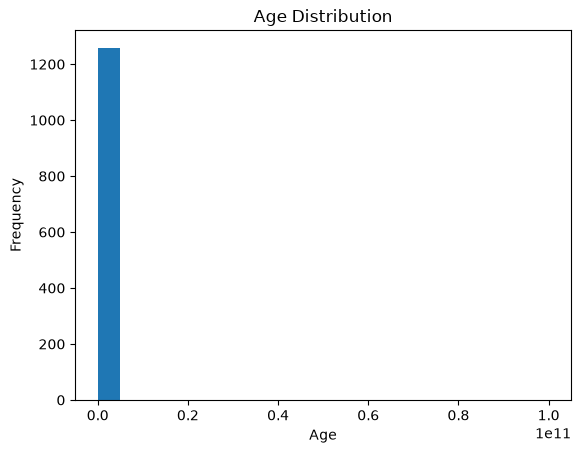

In [9]:
import matplotlib.pyplot as plt
plt.hist(df['Age'], bins=20)
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.title("Age Distribution")
plt.show()

In [10]:
print('Minimum age:', df['Age'].min(), 'Maximum age:',df['Age'].max())
print(df['Age'].value_counts().sort_index())

Minimum age: -1726 Maximum age: 99999999999
Age
-1726            1
-29              1
-1               1
 5               1
 8               1
 11              1
 18              7
 19              9
 20              6
 21             16
 22             21
 23             51
 24             46
 25             61
 26             75
 27             71
 28             68
 29             85
 30             63
 31             67
 32             82
 33             70
 34             65
 35             55
 36             37
 37             43
 38             39
 39             33
 40             33
 41             21
 42             20
 43             28
 44             11
 45             12
 46             12
 47              2
 48              6
 49              4
 50              6
 51              5
 53              1
 54              3
 55              3
 56              4
 57              3
 58              1
 60              2
 61              1
 62              1
 65              1
 7

**Observations regarding dataset**

Source: Survey regarding mental health within tech industry  
Objective: Display 'Age' distribution  

**Expectations**  
Minimum age of participant: Legal working age, i.e: Age >= 18  
Maximum age of participant: Depend on several factors, including the target audience of the study: i.e: Currently employed in tech? Retired from tech? Local age of retirement within country where fieldwork is being carried out

**Reality**  
Minimum age of participant: The current minimum age values recorded go below 18: 11, 8, 5, -1, -29, -1726
Maximum age of participant: The maximum age values clearly exceed current human life expectancy. Values such as 329 and 99999999999.

**Conclusion**  
Data type: Numeric(int64)  
Presence of blank values: False  
The above histogram describing age distribution was done without spotting and cleaning extreme values, considering context


In [19]:
df_filtered = df[(df['Age'] >= 18) & (df['Age'] <= 72)] # Age filter
df_filtered.to_csv('cleaned_age.csv', index=False) # Saving dataset with now filtered 'Age' column

**Loading updated dataset and plotting findings**

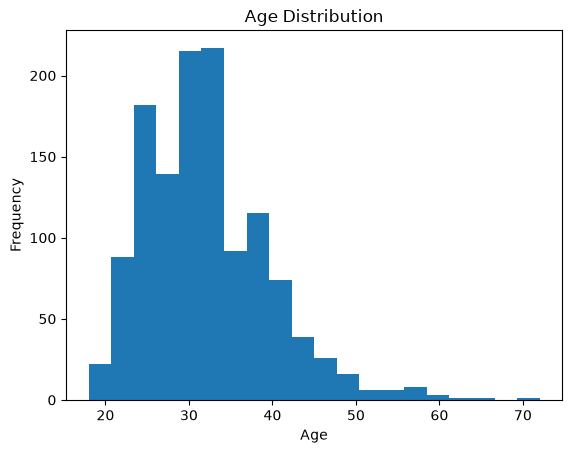

In [21]:
df = pd.read_csv('cleaned_age.csv')
plt.hist(df['Age'], bins=20)
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.title("Age Distribution")
plt.show()

**Mental health variation by Gender**

**Gender-wise frequency count**

In [13]:
gender_counts = df['Gender'].value_counts()
print(gender_counts)

Gender
Male                                              612
male                                              204
Female                                            121
M                                                 116
female                                             62
F                                                  38
m                                                  34
f                                                  15
Make                                                4
Woman                                               3
Male                                                3
Cis Male                                            2
Female                                              2
Man                                                 2
Female (trans)                                      2
Male-ish                                            1
maile                                               1
Trans-female                                        1
Cis Female           

**Classification**
1. Male
2. Female
3. Other

**Methodology of classication**
1. Male = Male, male, M, m, Make, Man, Cis Male, maile, Mal, Malle (CIS), msle, Mail, cis male, Malr, Cis Man.
1. Female = Female, female, F, f, Woman, Cis Female, Femake, woman, cis-female/femme, Female (cis), femail
1. Other = Female (trans), Male-ish, Trans-female, something kinda male?, queer/she/they, non-binary, Nah, Enby, fluid, Genderqueer, Androgyne, Agender, Guy (-ish) ^_^, male leaning androgynous, Trans woman, Neuter, 'ostensibly male, unsure what that really means'

Simplified method:
Male = Male + male + M + m
Female = Female + female + F + f

In [15]:
Male = 612 + 204 + 116 + 34
print(Male)

966


In [16]:
Female = 121 + 62 + 38 + 15
print(Female)

236


First impression from this dataset is that males are more likely to suffer from some mental condition within the technological industry

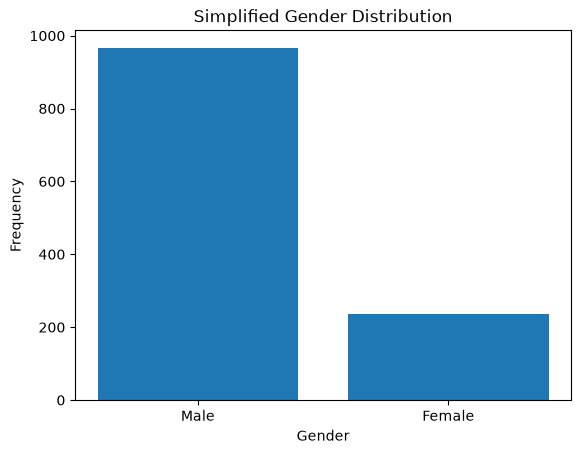

In [22]:
import matplotlib.pyplot as plt

gender = ['Male', 'Female']
frequency = [966, 236]

plt.bar(gender, frequency)

plt.xlabel('Gender')
plt.ylabel('Frequency')
plt.title('Simplified Gender Distribution')

plt.show()

In [25]:
df = pd.read_csv('cleaned_age.csv')
print(df['Country'].unique())

<ArrowStringArray>
[         'United States',                 'Canada',         'United Kingdom',
               'Bulgaria',                 'France',               'Portugal',
            'Netherlands',            'Switzerland',                 'Poland',
              'Australia',                'Germany',                 'Russia',
                 'Mexico',                 'Brazil',               'Slovenia',
             'Costa Rica',                'Austria',                'Ireland',
                  'India',           'South Africa',                  'Italy',
                 'Sweden',               'Colombia',                 'Latvia',
                'Romania',                'Belgium',            'New Zealand',
                  'Spain',                'Finland',                'Uruguay',
                 'Israel', 'Bosnia and Herzegovina',                'Hungary',
              'Singapore',                  'Japan',                'Nigeria',
                'Croatia',       

In [26]:
print(df['Country'].value_counts())

Country
United States             746
United Kingdom            184
Canada                     72
Germany                    45
Netherlands                27
Ireland                    27
Australia                  21
France                     13
India                      10
New Zealand                 8
Switzerland                 7
Poland                      7
Italy                       7
Sweden                      7
Brazil                      6
South Africa                6
Belgium                     6
Israel                      5
Bulgaria                    4
Singapore                   4
Russia                      3
Mexico                      3
Austria                     3
Finland                     3
Portugal                    2
Colombia                    2
Croatia                     2
Denmark                     2
Greece                      2
Slovenia                    1
Costa Rica                  1
Latvia                      1
Romania                     1
Sp

Country with highest count of mental health issues within tech: United States of America  
Countries with lowest count of mental health issues within tech:  
Slovenia                    1  
Costa Rica                  1  
Latvia                      1  
Romania                     1  
Spain                       1  
Uruguay                     1  
Bosnia and Herzegovina      1  
Hungary                     1  
Japan                       1  
Nigeria                     1  
Norway                      1  
Thailand                    1  
Moldova                     1  
Georgia                     1  
China                       1  
Czech Republic              1  
Philippines                 1  
  